In [28]:
import os 
from dotenv import load_dotenv
load_dotenv()

from io import BytesIO
from PIL import Image
 
from transformers import CLIPProcessor, CLIPModel
import torch.nn.functional as F

import torch
import ipyplot

import requests

In [29]:
# Pixabay API
API_URL_BASE = "https://pixabay.com/api/?key="
PIXABAY_API_KEY = os.getenv("PIXABAY_API_KEY")

In [30]:
def download_pixabay_images_from_category(search_keyword, no_imgs=100):
    
    url = f"{API_URL_BASE}{PIXABAY_API_KEY}&q={search_keyword.lower()}&image_type=photo&safesearch=true&per_page={no_imgs}"
    
    response = requests.get(url)
    output = response.json()

    images =[]
    for each in output["hits"]:
        imageurl = each["webformatURL"]
        response = requests.get(imageurl)
        image = Image.open(BytesIO(response.content)).convert("RGB")
        images.append(image)

    print ("Total no of images retrived: ",len(images))
    return images

def download_all_pixabay_images(categories, no_imgs=100):
    all_images = []
    no_imgs_per_category = no_imgs // len(categories)
    
    for category in categories:
        print(f"Downloading {no_imgs_per_category} images for category: {category}")
        images = download_pixabay_images_from_category(category, no_imgs_per_category)
        all_images.extend(images)
    
    print(f"Total images downloaded: {len(all_images)}")
    return all_images

In [31]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
images = download_all_pixabay_images(categories=["desert", "beach", "cat", "tiger", "jaguar"], no_imgs=100)

Total no of images retrived:  20
Total no of images retrived:  20
Total no of images retrived:  20
Total no of images retrived:  20
Total no of images retrived:  20
Total images downloaded: 100



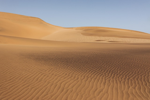
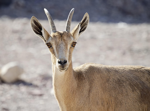
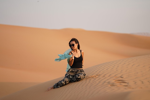
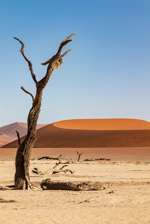
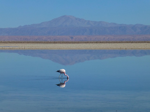
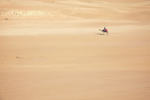
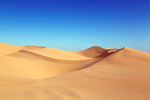
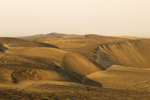
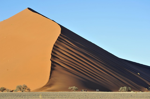
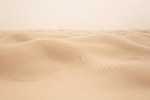
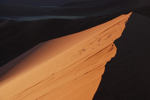
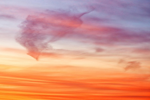
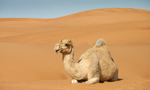
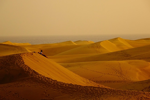
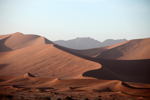
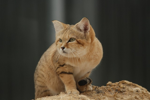
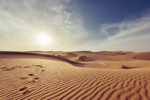
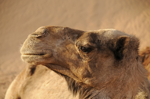
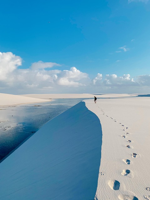
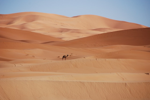
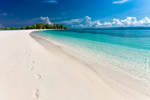
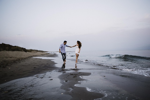
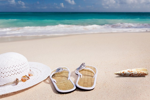
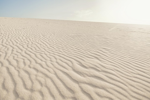
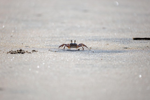
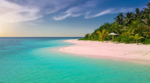
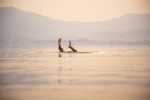
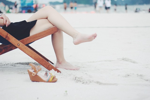
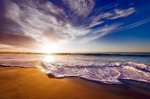
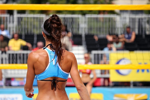
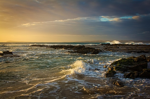
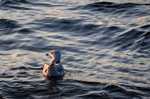
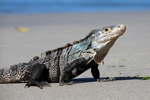
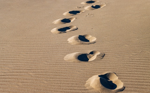
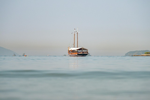
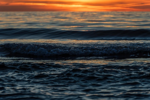
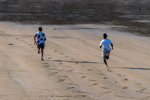
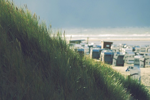
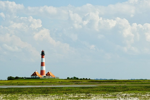
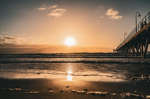
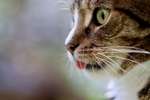
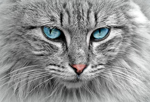
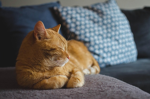
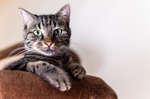
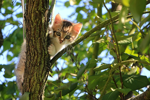
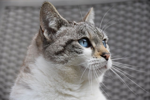
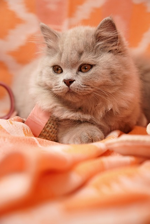
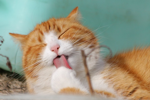
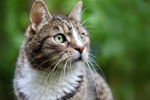
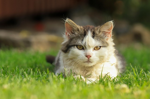
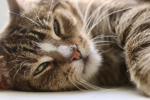
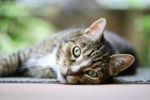
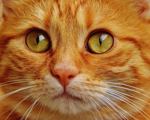
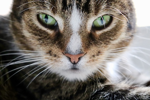
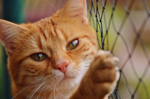
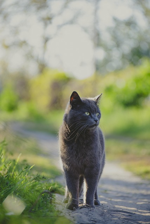
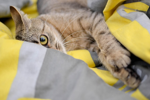
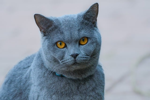
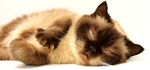
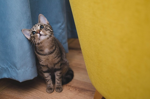
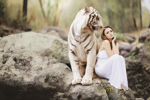
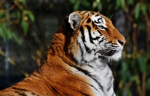
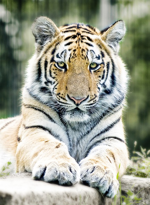
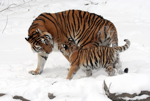
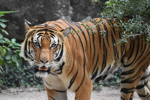
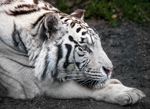
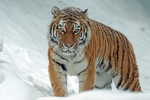
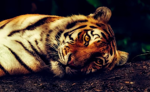
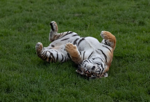
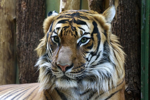
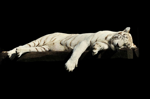
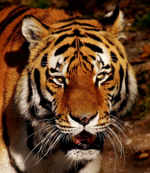
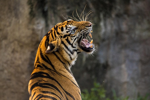
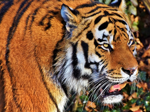
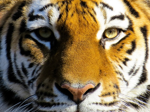
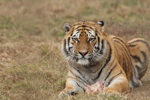
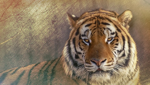
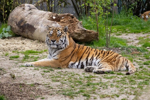
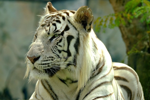
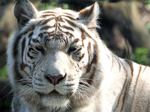
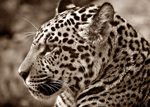
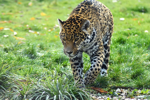
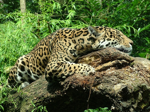
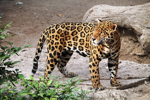
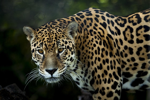
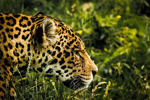
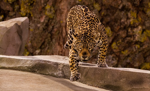
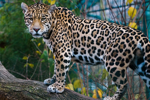
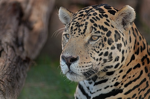
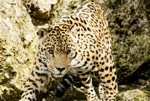
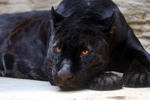
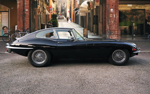
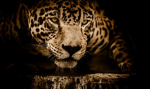
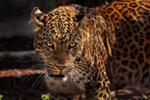
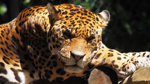
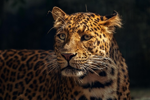
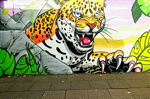
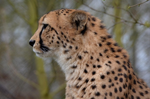
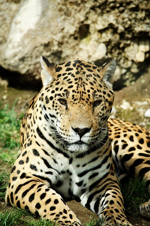
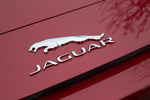


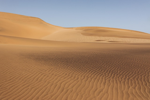
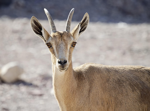
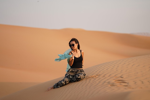
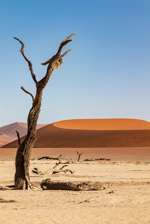
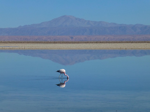
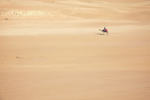
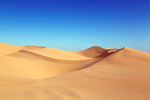
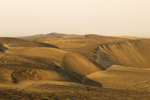
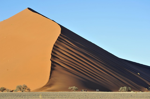
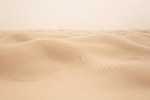
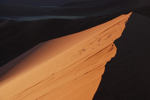
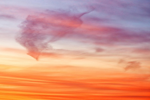
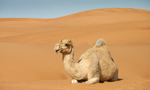
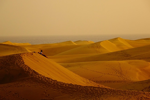
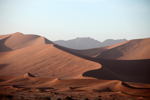
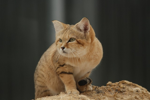
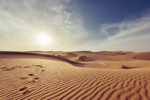
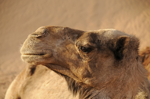
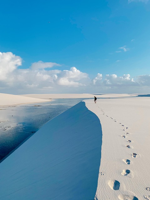
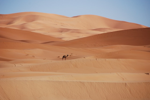
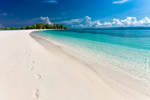
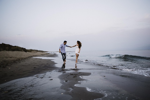
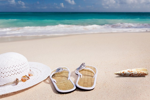
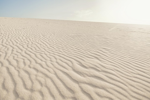
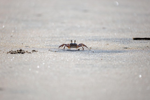
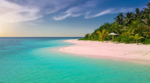
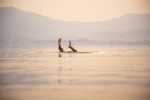
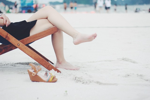
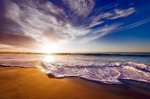
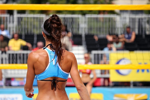
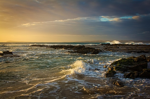
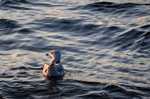
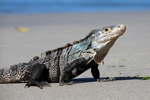
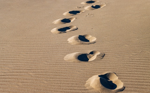
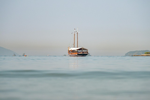
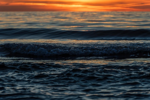
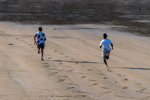
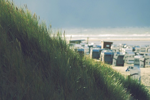
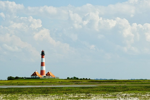
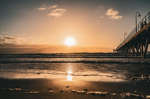
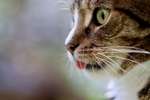
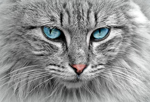
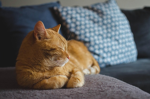
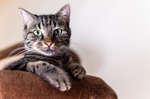
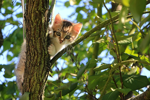
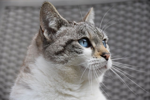
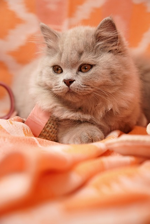
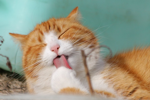
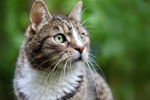
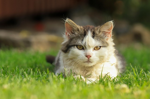
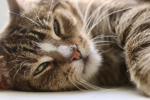
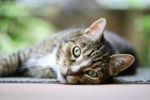
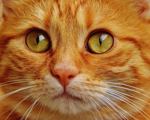
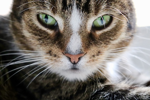
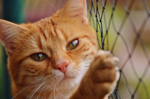
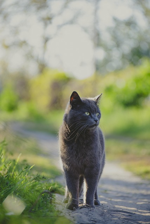
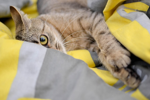
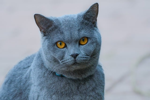
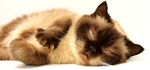
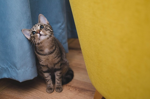
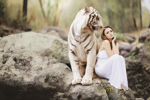
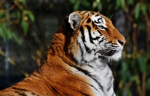
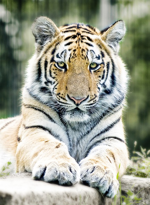
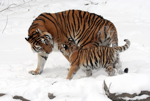
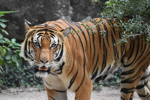
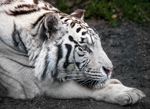
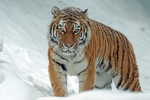
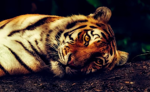
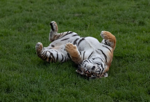
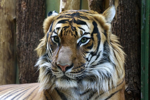
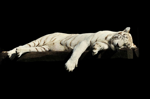
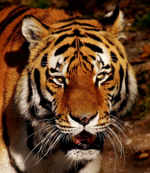
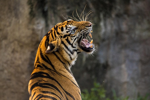
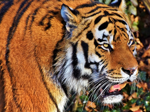
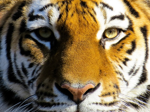
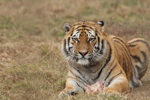
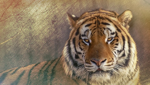
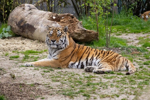
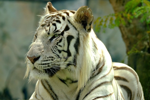
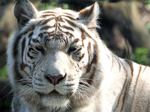
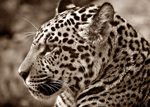
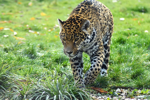
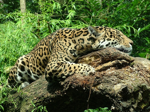
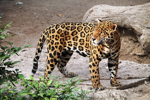
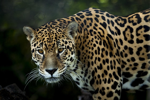
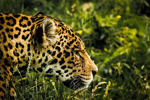
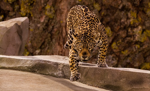
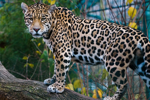
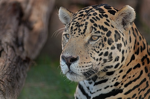
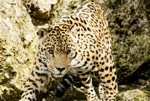
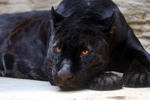
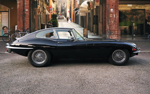
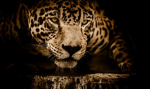
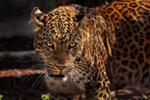
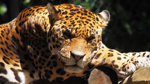
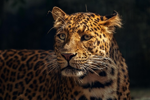
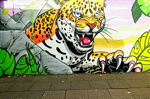
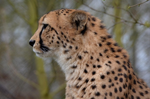
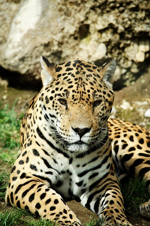
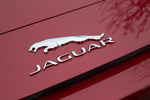

In [32]:
ipyplot.plot_images(images, max_images=100, img_width=150)

# Compute similarities for pixabay images

In [37]:
image_description = "jaguar"  
target_image = Image.open("./images/img2img_targets/jaguar.jpg") 

In [38]:
with torch.no_grad():
    inputs = processor(images=[target_image]+images, return_tensors="pt", padding=True)
    image_features = model.get_image_features(**inputs)
    image_features = F.normalize(image_features, p=2, dim=-1)

target = image_features[0]
rest = image_features[1:]

# calculate cosine similarities
similarities = rest @ target.T  # shape: [n-1]

# get top-k similar images
topk = torch.topk(similarities, k=5)
top_scores = topk.values
top_indices = topk.indices
top_images = [images[i] for i in top_indices]

Scores: tensor([0.9457, 0.9441, 0.9381, 0.9278, 0.9245])



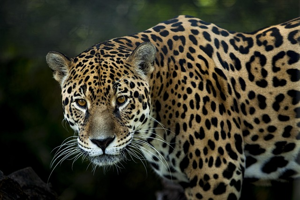
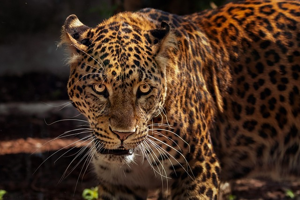
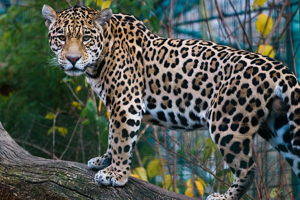
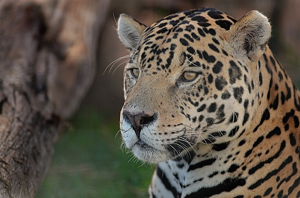
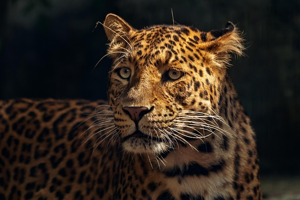


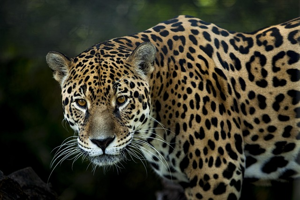
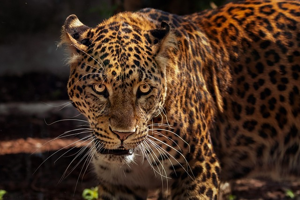
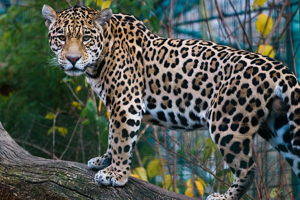
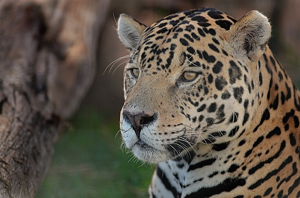
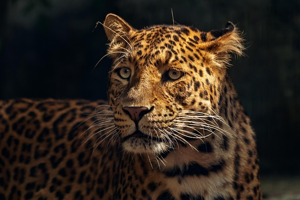

In [39]:
print (f"Scores: {top_scores}")
ipyplot.plot_images(top_images, img_width=300)

# Saving results

In [40]:
SAVE_BASE_PATH = os.path.join('./images/semantic_search_results/pixabay/img2img/', image_description.replace(' ', '_'))
if not os.path.exists(SAVE_BASE_PATH):
    os.makedirs(SAVE_BASE_PATH)

for i, (image, score) in enumerate(zip(top_images, top_scores)):
    image.save(os.path.join(SAVE_BASE_PATH, f"{i+1}_score_{score:.2f}.jpg"))